<a href="https://colab.research.google.com/github/dede0702/Image-Analysis-for-Ad-Differentiation/blob/Sprint-2/Image_Analysis_for_Ad_Differentiation_PT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Sprint 2: Comparação Visual de Anúncios com Modelos de Similaridade
```





```
0. Setup e Importações
```



In [16]:
!pip install tensorflow Pillow scikit-learn matplotlib seaborn umap-learn plotly

In [17]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Para matriz de similaridade mais bonita
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, MobileNetV2 # Opções de modelos
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
# import umap # Descomente se for usar UMAP para redução ou cluster
# import plotly.express as px # Para visualizações interativas (opcional)
from PIL import Image, UnidentifiedImageError
import shutil
import random

In [18]:
# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.18.0




```
1. PREPARAÇÃO DO CONJUNTO DE DADOS
```



In [19]:
# Montar o Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# ------------------------------------------------------------------------------------
# ATENÇÃO USUÁRIO:
# Modifique 'original_dataset_root_path_drive' para apontar para a pasta raiz do seu dataset no Google Drive.
# Dentro desta pasta, crie uma subpasta chamada 'ads_for_similarity'
# (ou o nome que preferir, mas atualize 'subfolder_for_ads' abaixo)
# contendo as imagens de anúncios que você quer comparar.
#
# Estrutura esperada no Drive:
# SEU_CAMINHO_NO_DRIVE/
# ├── ads_for_similarity/
# │   ├── anuncio1.jpeg
# │   ├── anuncio2.jpg
# │   ├── anuncio_hp_campanha_x.png (será convertido para jpeg)
# │   └── ...
# ------------------------------------------------------------------------------------

In [21]:
original_dataset_root_path_drive = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/SPRINT2_HP_Challenge_Dataset') # <--- MUDE ESTE CAMINHO
subfolder_for_ads = "ads_for_similarity" # Nome da subpasta com os anúncios para esta sprint

# Diretório local para imagens processadas
processed_ads_local_path = pathlib.Path("dataset_processed_sprint2_local")
if processed_ads_local_path.exists():
    shutil.rmtree(processed_ads_local_path)
processed_ads_local_path.mkdir(exist_ok=True)
print(f"Dataset original (raiz no Drive): {original_dataset_root_path_drive}")
print(f"Subpasta de anúncios a ser processada: {subfolder_for_ads}")
print(f"Imagens válidas serão copiadas e processadas para (local): {processed_ads_local_path}\n")

# Parâmetros para processamento de imagem
INPUT_IMAGE_EXTENSIONS_ACCEPTED = ['.jpeg', '.jpg', '.png', '.bmp'] # Aceita mais formatos na entrada
TARGET_SAVE_EXTENSION = '.jpeg' # Salva tudo como JPEG
TARGET_PIL_FORMAT = 'JPEG'

def process_and_copy_sprint2_images(source_base_path, dest_base_path, source_subfolder_name):
    source_folder = source_base_path / source_subfolder_name
    dest_folder = dest_base_path # Salva diretamente na pasta de destino local

    if not source_folder.exists():
        print(f"ERRO: Pasta de origem '{source_folder}' não encontrada no Google Drive. Verifique o caminho e o nome da subpasta.")
        return 0, 0, 0

    dest_folder.mkdir(parents=True, exist_ok=True)
    print(f"\nProcessando pasta: {source_folder} -> {dest_folder}")

    _processed_count = 0
    _skipped_ext_count = 0
    _error_count = 0

    image_files = [p for ext in INPUT_IMAGE_EXTENSIONS_ACCEPTED for p in source_folder.glob(f'*{ext}')]
    print(f"Encontrados {len(image_files)} arquivos de imagem em '{source_folder}'.")


    for input_file_path in image_files:
        if input_file_path.is_file():
            try:
                img = Image.open(input_file_path)
                img.verify()
                img = Image.open(input_file_path) # Reabrir após verify

                output_stem = input_file_path.stem
                output_filename = output_stem + TARGET_SAVE_EXTENSION
                current_output_file_path = dest_folder / output_filename

                counter = 0
                while current_output_file_path.exists():
                    counter += 1
                    output_filename = f"{output_stem}_{counter}{TARGET_SAVE_EXTENSION}"
                    current_output_file_path = dest_folder / output_filename

                img.convert('RGB').save(current_output_file_path, TARGET_PIL_FORMAT)
                _processed_count += 1

            except UnidentifiedImageError:
                print(f"  IGNORADO (Pillow UnidentifiedImageError): {input_file_path.name}")
                _error_count += 1
            except Exception as e:
                print(f"  ERRO ao processar {input_file_path.name}: {e}")
                _error_count += 1
        else: # Teoricamente não deveria acontecer com glob, mas para segurança
             _skipped_ext_count +=1


    print(f"  Concluído para '{source_subfolder_name}': {_processed_count} processadas, {_skipped_ext_count} ignoradas (não arquivo ou extensão), {_error_count} erros.")
    return _processed_count, _skipped_ext_count, _error_count

Dataset original (raiz no Drive): /content/drive/MyDrive/Colab Notebooks/SPRINT2_HP_Challenge_Dataset
Subpasta de anúncios a ser processada: ads_for_similarity
Imagens válidas serão copiadas e processadas para (local): dataset_processed_sprint2_local



In [22]:
# Processar as imagens para a Sprint 2
print(f"--- Iniciando Pré-processamento e Cópia de Imagens (Drive -> Local) para Sprint 2 ---")
p, s, e = process_and_copy_sprint2_images(original_dataset_root_path_drive, processed_ads_local_path, subfolder_for_ads)

if p == 0 and e > 0:
    print(f"ERRO CRÍTICO: Nenhuma imagem foi processada com sucesso e ocorreram {e} erros. Verifique os logs e o dataset.")
elif p == 0:
    print(f"AVISO: Nenhuma imagem foi processada. A pasta '{original_dataset_root_path_drive / subfolder_for_ads}' pode estar vazia ou conter apenas arquivos não suportados.")
else:
    print(f"\nPré-processamento concluído: {p} imagens processadas para '{processed_ads_local_path}'.")

--- Iniciando Pré-processamento e Cópia de Imagens (Drive -> Local) para Sprint 2 ---

Processando pasta: /content/drive/MyDrive/Colab Notebooks/SPRINT2_HP_Challenge_Dataset/ads_for_similarity -> dataset_processed_sprint2_local
Encontrados 60 arquivos de imagem em '/content/drive/MyDrive/Colab Notebooks/SPRINT2_HP_Challenge_Dataset/ads_for_similarity'.
  Concluído para 'ads_for_similarity': 60 processadas, 0 ignoradas (não arquivo ou extensão), 0 erros.

Pré-processamento concluído: 60 imagens processadas para 'dataset_processed_sprint2_local'.




```
2. CONSTRUÇÃO DE EMBEDDINGS VISUAIS
```



In [23]:
print("\n\n--- 2. Geração de Embeddings Visuais ---")



--- 2. Geração de Embeddings Visuais ---


In [24]:
# Escolha do modelo
# Opções: "ResNet50", "EfficientNetB0", "MobileNetV2"
MODEL_CHOICE = "ResNet50" # Mude aqui para testar outros

IMG_HEIGHT, IMG_WIDTH = 224, 224 # Tamanho padrão para muitos modelos

if MODEL_CHOICE == "ResNet50":
    base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    preprocess_input_func = resnet_preprocess
    print("Usando ResNet50 para embeddings.")
elif MODEL_CHOICE == "EfficientNetB0":
    base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    preprocess_input_func = efficientnet_preprocess
    print("Usando EfficientNetB0 para embeddings.")
elif MODEL_CHOICE == "MobileNetV2":
    base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    preprocess_input_func = mobilenet_preprocess
    print("Usando MobileNetV2 para embeddings.")
else:
    raise ValueError("Escolha de modelo inválida.")

embedding_model = Model(inputs=base_model.input, outputs=base_model.output)

def extract_features(img_path, model, preprocess_func, target_size):
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img)
    expanded_img_array = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_func(expanded_img_array)
    features = model.predict(preprocessed_img, verbose=0)
    return features.flatten()

Usando ResNet50 para embeddings.


In [25]:
# Carregar imagens processadas localmente
ad_image_paths = sorted(list(processed_ads_local_path.glob(f'*{TARGET_SAVE_EXTENSION}')))
all_embeddings = []
loaded_pil_images = []
image_filenames = []

if not ad_image_paths:
    print(f"Nenhuma imagem {TARGET_SAVE_EXTENSION} encontrada em '{processed_ads_local_path}'. Pulando extração de embeddings.")
else:
    print(f"Extraindo embeddings de {len(ad_image_paths)} imagens...")
    for img_path in ad_image_paths:
        try:
            features = extract_features(img_path, embedding_model, preprocess_input_func, (IMG_HEIGHT, IMG_WIDTH))
            all_embeddings.append(features)
            loaded_pil_images.append(Image.open(img_path))
            image_filenames.append(img_path.name)
        except Exception as ex:
            print(f"Erro ao extrair features de {img_path.name}: {ex}")
            continue

    if all_embeddings:
        all_embeddings = np.array(all_embeddings)
        print(f"Shape dos embeddings gerados: {all_embeddings.shape}")
    else:
        print("Nenhum embedding foi gerado. Verifique os erros anteriores.")
        all_embeddings = None # Garante que é None se a lista estiver vazia


Extraindo embeddings de 60 imagens...
Shape dos embeddings gerados: (60, 2048)


In [26]:
# Helper para plotar imagens (usado para mostrar pares)
def plot_image_pair(img1_pil, img2_pil, title1="Imagem 1", title2="Imagem 2", main_title=""):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img1_pil)
    axes[0].set_title(title1)
    axes[0].axis('off')
    axes[1].imshow(img2_pil)
    axes[1].set_title(title2)
    axes[1].axis('off')
    fig.suptitle(main_title)
    plt.show()



```
3. MEDIÇÃO DE SIMILARIDADE ENTRE ANÚNCIOS
```





--- 3. Medição de Similaridade ---


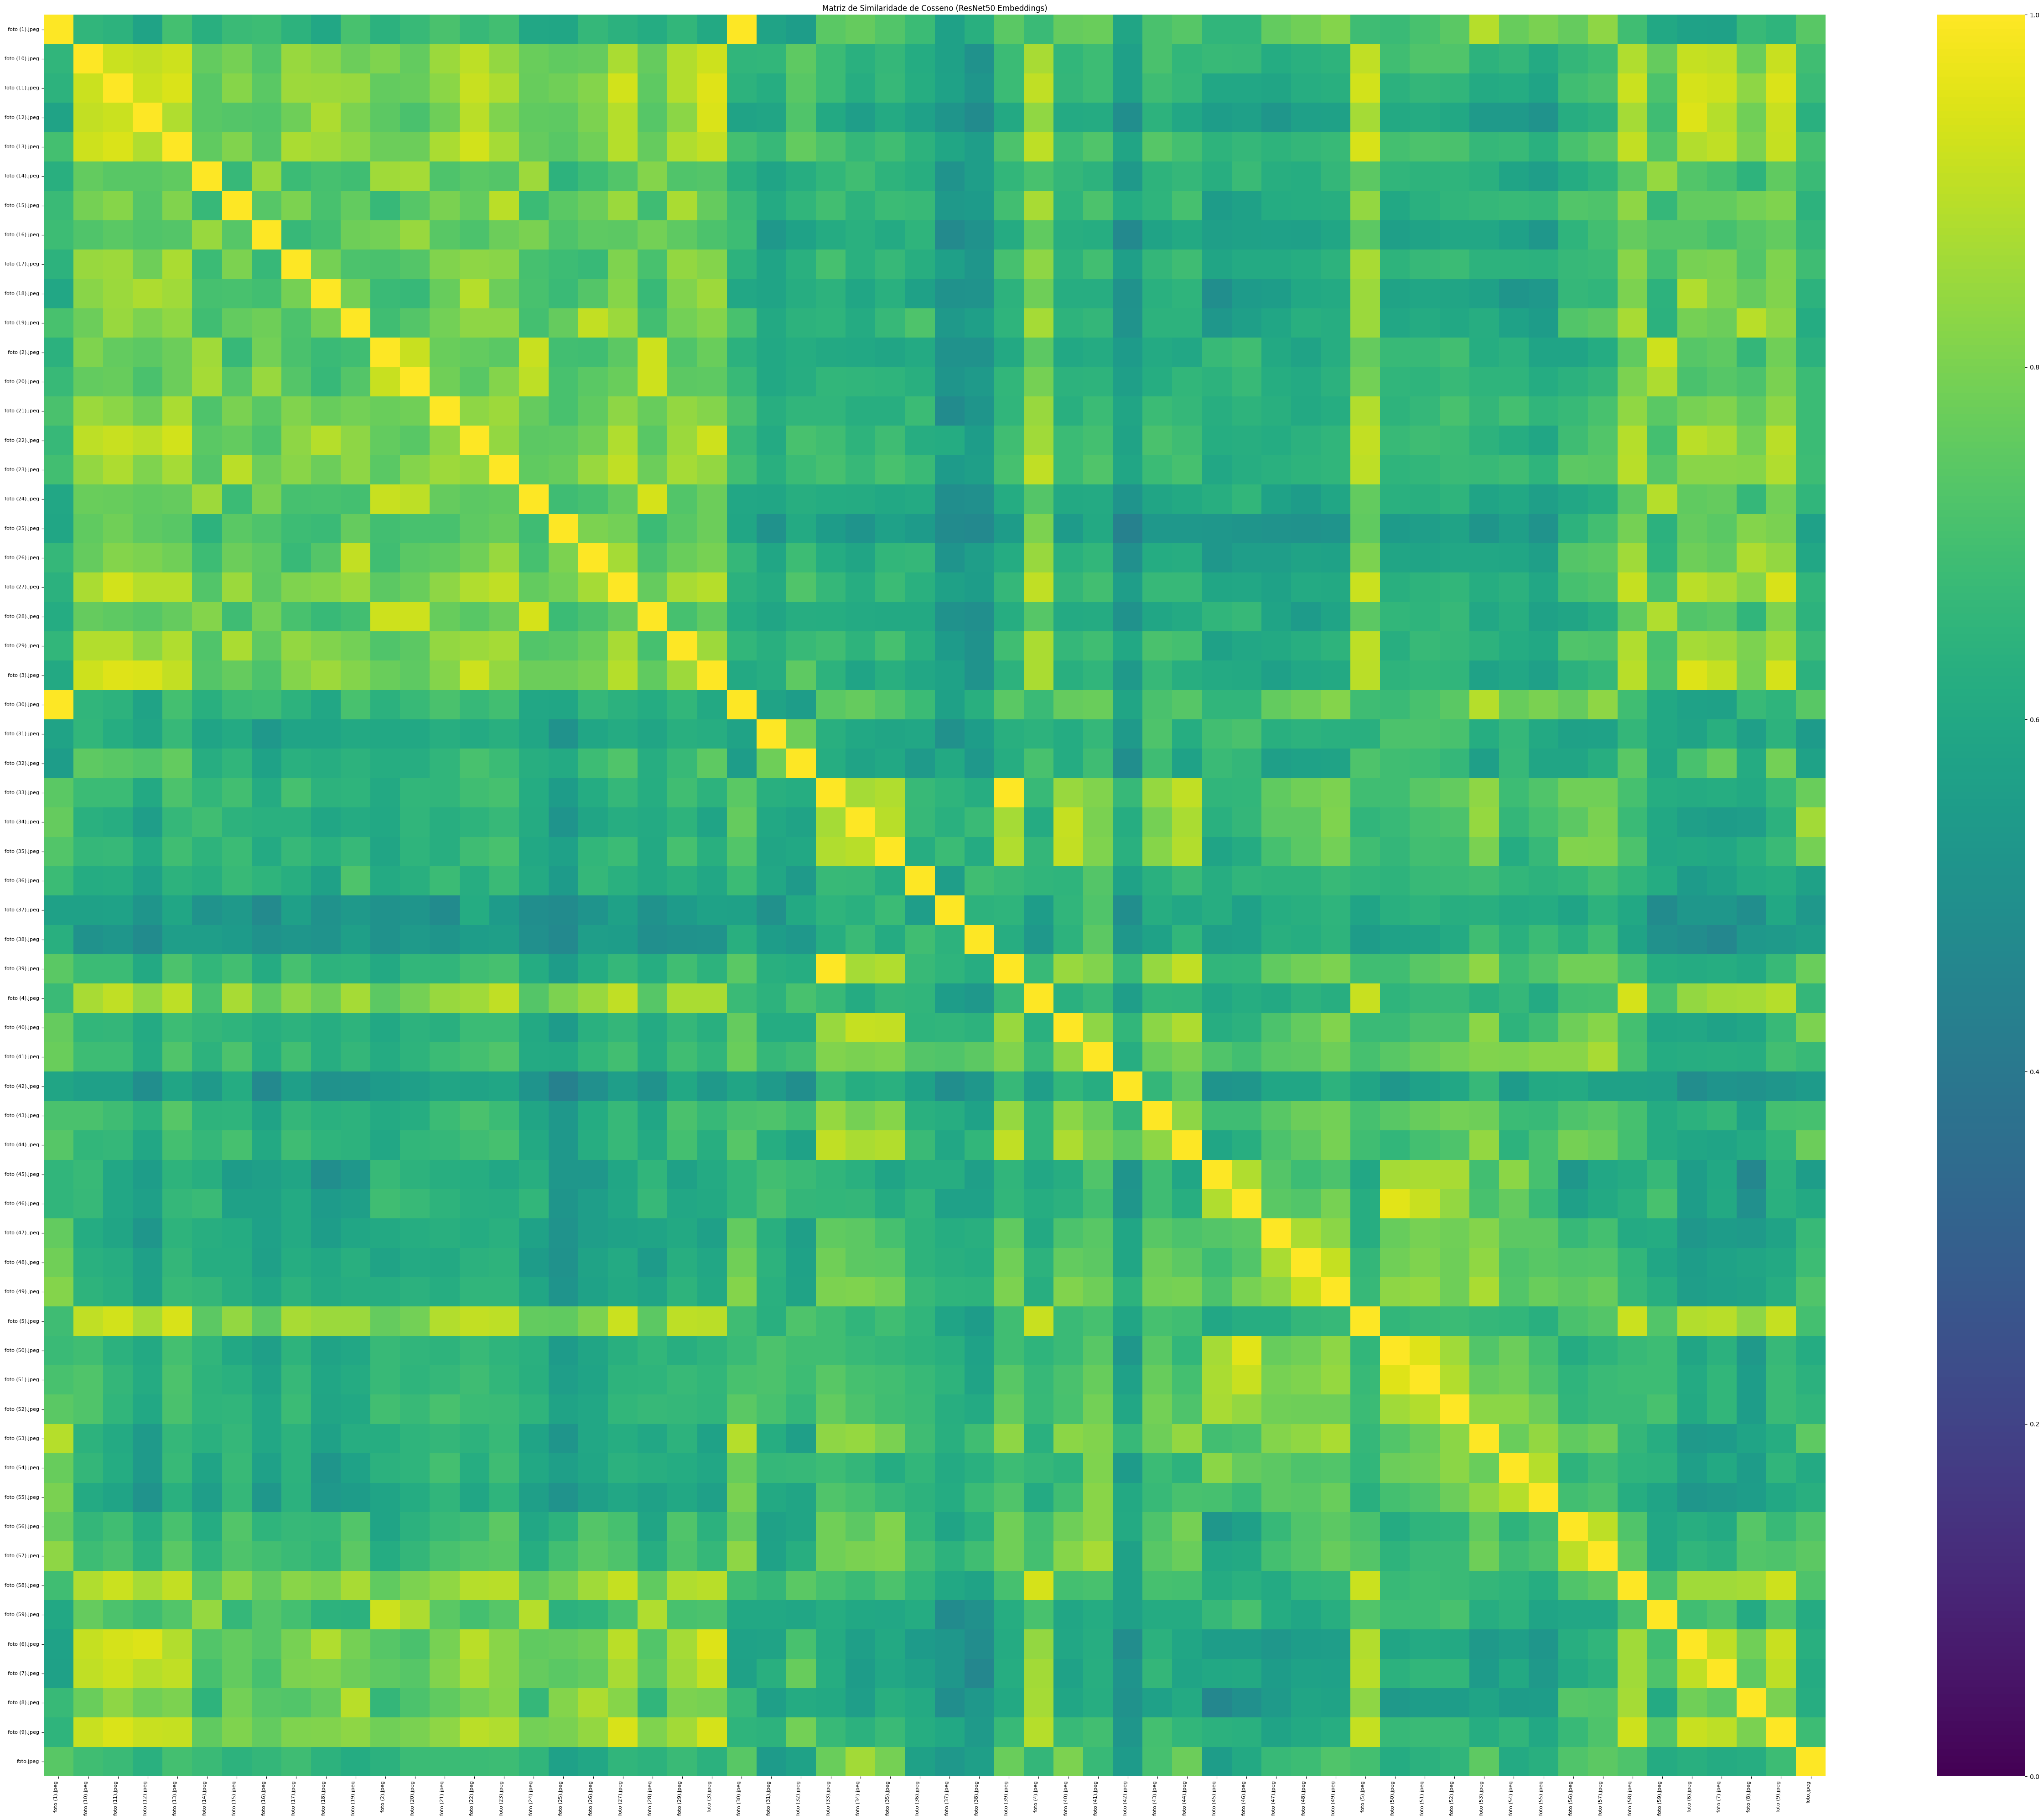


Top 3 Pares Mais Semelhantes:
- 'foto (1).jpeg' e 'foto (30).jpeg': Similaridade = 1.0000


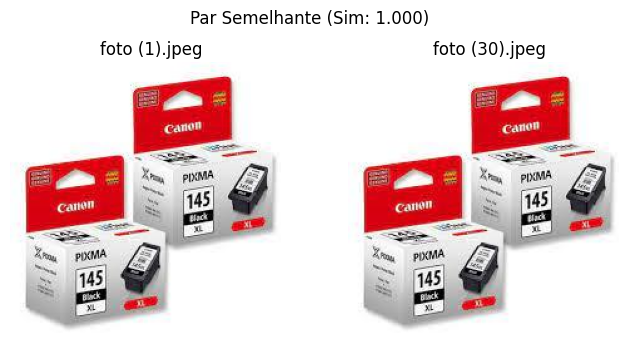

- 'foto (33).jpeg' e 'foto (39).jpeg': Similaridade = 1.0000


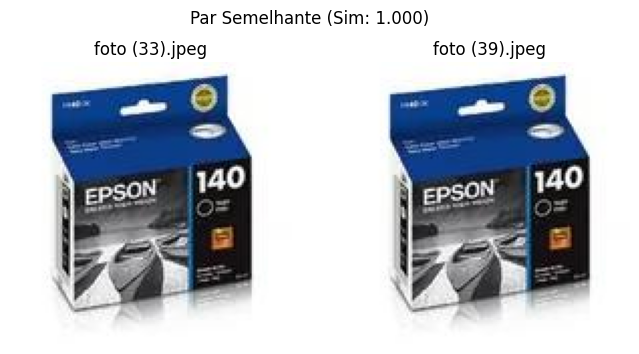

- 'foto (46).jpeg' e 'foto (50).jpeg': Similaridade = 0.9570


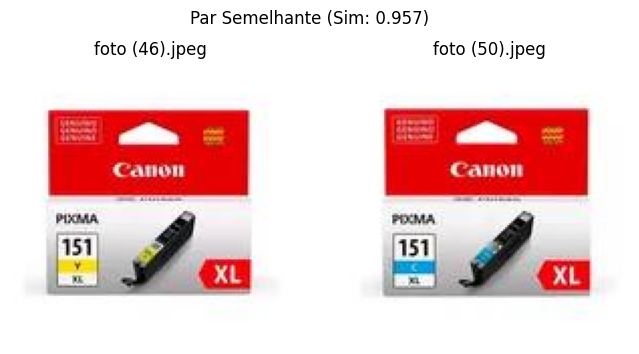


Top 3 Pares Mais Diferentes:
- 'foto (25).jpeg' e 'foto (42).jpeg': Similaridade = 0.4354


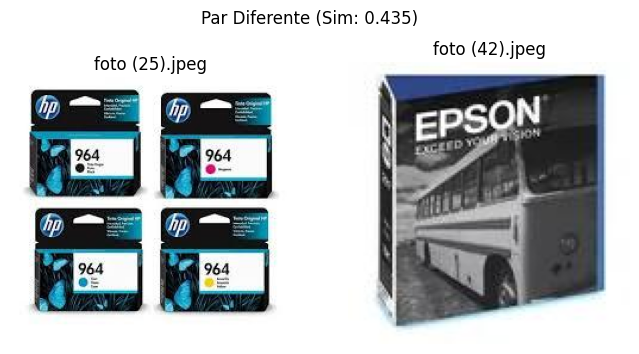

- 'foto (38).jpeg' e 'foto (7).jpeg': Similaridade = 0.4618


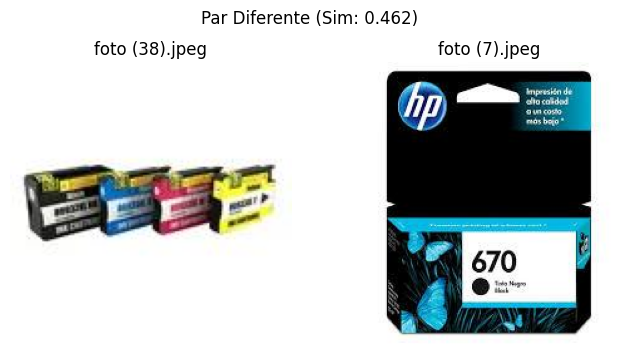

- 'foto (45).jpeg' e 'foto (8).jpeg': Similaridade = 0.4635


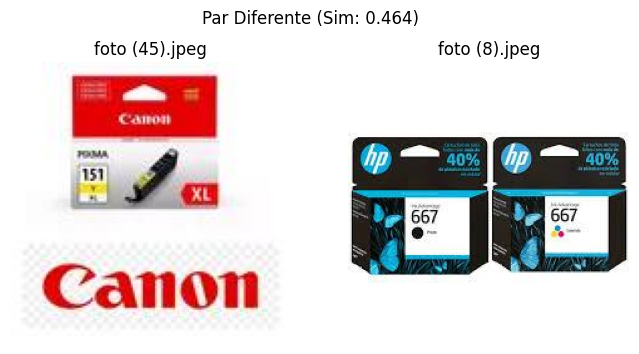


Detectando Pares com Similaridade > 0.98 (Potenciais Duplicatas):
- 'foto (1).jpeg' e 'foto (30).jpeg': Similaridade = 1.0000
- 'foto (33).jpeg' e 'foto (39).jpeg': Similaridade = 1.0000


In [27]:
if all_embeddings is not None and len(all_embeddings) > 1:
    print("\n\n--- 3. Medição de Similaridade ---")
    # Calcular similaridade de cosseno
    similarity_matrix = cosine_similarity(all_embeddings)

    # Visualizar matriz de similaridade
    plt.figure(figsize=(max(8, len(image_filenames)//1.2), max(6, len(image_filenames)//1.5)))
    sns.heatmap(similarity_matrix, annot=False, cmap='viridis', vmin=0, vmax=1,
                xticklabels=image_filenames, yticklabels=image_filenames)
    plt.title(f'Matriz de Similaridade de Cosseno ({MODEL_CHOICE} Embeddings)')
    plt.xticks(rotation=90, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    # Identificar e mostrar pares mais semelhantes e diferentes
    # (Excluindo auto-similaridade e duplicatas de pares)
    num_images = len(image_filenames)
    similarities = []
    for i in range(num_images):
        for j in range(i + 1, num_images):
            similarities.append(((i, j), image_filenames[i], image_filenames[j], similarity_matrix[i, j]))

    # Ordenar por similaridade
    similarities.sort(key=lambda x: x[3], reverse=True)

    print("\nTop 3 Pares Mais Semelhantes:")
    for k in range(min(3, len(similarities))):
        pair_info = similarities[k]
        print(f"- '{pair_info[1]}' e '{pair_info[2]}': Similaridade = {pair_info[3]:.4f}")
        idx1, idx2 = pair_info[0]
        plot_image_pair(loaded_pil_images[idx1], loaded_pil_images[idx2],
                        pair_info[1], pair_info[2],
                        f"Par Semelhante (Sim: {pair_info[3]:.3f})")


    print("\nTop 3 Pares Mais Diferentes:")
    for k in range(min(3, len(similarities))):
        pair_info = similarities[-(k+1)] # Pega do final da lista ordenada
        print(f"- '{pair_info[1]}' e '{pair_info[2]}': Similaridade = {pair_info[3]:.4f}")
        idx1, idx2 = pair_info[0]
        plot_image_pair(loaded_pil_images[idx1], loaded_pil_images[idx2],
                        pair_info[1], pair_info[2],
                        f"Par Diferente (Sim: {pair_info[3]:.3f})")

    # Detectar duplicatas ou quase duplicatas
    DUPLICATE_THRESHOLD = 0.98 # Ajuste este valor
    print(f"\nDetectando Pares com Similaridade > {DUPLICATE_THRESHOLD} (Potenciais Duplicatas):")
    found_duplicates = False
    for pair_info in similarities:
        if pair_info[3] > DUPLICATE_THRESHOLD:
            print(f"- '{pair_info[1]}' e '{pair_info[2]}': Similaridade = {pair_info[3]:.4f}")
            found_duplicates = True
    if not found_duplicates:
        print("  Nenhuma duplicata ou quase duplicata encontrada com este threshold.")

else:
    print("\n\nPulando Medição de Similaridade (sem embeddings ou menos de 2 imagens).")



```
4. VISUALIZAÇÃO DOS EMBEDDINGS (t-SNE)
```





--- 4. Visualização 2D dos Embeddings com t-SNE ---


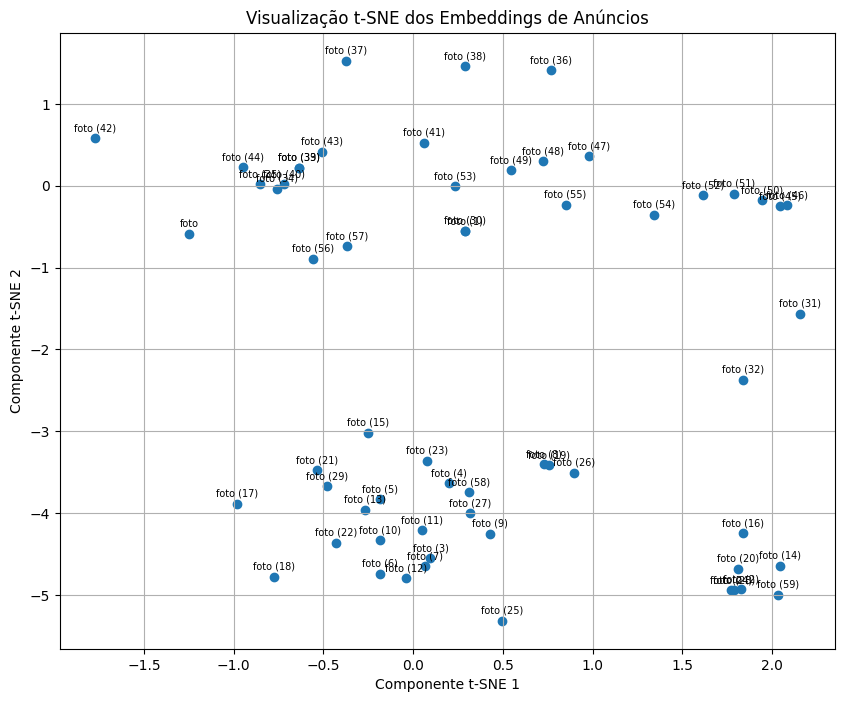

In [28]:
if all_embeddings is not None and len(all_embeddings) > 2 : # t-SNE precisa de mais de 1 amostra
    print("\n\n--- 4. Visualização 2D dos Embeddings com t-SNE ---")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_embeddings)-1), max_iter=1000, metric='cosine')
    embeddings_2d = tsne.fit_transform(all_embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
    plt.title('Visualização t-SNE dos Embeddings de Anúncios')
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')

    # Adicionar anotações (nomes dos arquivos)
    for i, filename in enumerate(image_filenames):
        plt.annotate(filename.split('.')[0][:15], # Nome curto
                     (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=7)
    plt.grid(True)
    plt.show()

    # Opcional: Visualização interativa com Plotly (descomente se Plotly estiver instalado)
    # if len(image_filenames) == len(embeddings_2d):
    #     try:
    #         import plotly.express as px
    #         fig = px.scatter(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1],
    #                          text=image_filenames, title="Visualização t-SNE Interativa")
    #         fig.update_traces(textposition='top center')
    #         fig.show()
    #     except ImportError:
    #         print("Plotly não instalado. Pulando visualização interativa.")
    # else:
    #     print("Número de nomes de arquivo e embeddings 2D não coincidem para Plotly.")

else:
    print("\n\nPulando Visualização t-SNE (sem embeddings ou menos de 3 imagens).")




```
5. CLUSTERIZAÇÃO E AGRUPAMENTO (OPCIONAL - KMeans)
```





--- 5. Clusterização com KMeans (Opcional) ---
Resultados do Clustering (KMeans com 3 clusters):

Cluster 0:
  - foto (10).jpeg
  - foto (11).jpeg
  - foto (12).jpeg
  - foto (13).jpeg
  - foto (15).jpeg
  - foto (17).jpeg
  - foto (18).jpeg
  - foto (19).jpeg
  - foto (21).jpeg
  - foto (22).jpeg
  - foto (23).jpeg
  - foto (25).jpeg
  - foto (26).jpeg
  - foto (27).jpeg
  - foto (29).jpeg
  - foto (3).jpeg
  - foto (32).jpeg
  - foto (4).jpeg
  - foto (5).jpeg
  - foto (58).jpeg
  - foto (6).jpeg
  - foto (7).jpeg
  - foto (8).jpeg
  - foto (9).jpeg

Cluster 1:
  - foto (1).jpeg
  - foto (30).jpeg
  - foto (31).jpeg
  - foto (33).jpeg
  - foto (34).jpeg
  - foto (35).jpeg
  - foto (36).jpeg
  - foto (37).jpeg
  - foto (38).jpeg
  - foto (39).jpeg
  - foto (40).jpeg
  - foto (41).jpeg
  - foto (42).jpeg
  - foto (43).jpeg
  - foto (44).jpeg
  - foto (45).jpeg
  - foto (46).jpeg
  - foto (47).jpeg
  - foto (48).jpeg
  - foto (49).jpeg
  - foto (50).jpeg
  - foto (51).jpeg
  - foto (5

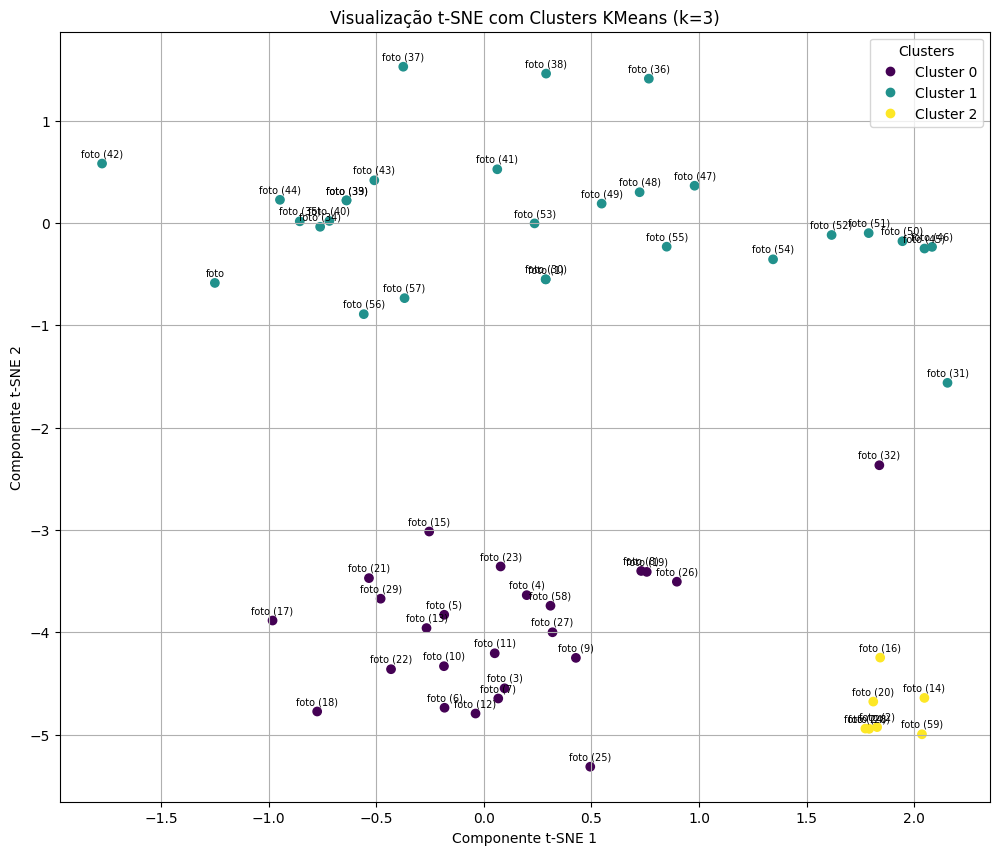

In [29]:
if all_embeddings is not None and len(all_embeddings) >= 3: # KMeans precisa de amostras suficientes
    print("\n\n--- 5. Clusterização com KMeans (Opcional) ---")
    num_clusters = min(3, len(all_embeddings)) # Exemplo: 3 clusters, ou menos se poucas imagens
                                            # Ajuste este valor conforme o seu dataset
    if num_clusters > 0:
        kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
        cluster_labels = kmeans.fit_predict(all_embeddings)

        print(f"Resultados do Clustering (KMeans com {num_clusters} clusters):")
        for i in range(num_clusters):
            print(f"\nCluster {i}:")
            cluster_images_filenames = [image_filenames[j] for j, label in enumerate(cluster_labels) if label == i]
            for fname in cluster_images_filenames:
                print(f"  - {fname}")

        # Visualizar clusters no gráfico t-SNE (se t-SNE foi calculado)
        if 'embeddings_2d' in locals() and embeddings_2d is not None:
            plt.figure(figsize=(12, 10))
            scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap='viridis')
            plt.title(f'Visualização t-SNE com Clusters KMeans (k={num_clusters})')
            plt.xlabel('Componente t-SNE 1')
            plt.ylabel('Componente t-SNE 2')
            # Adicionar anotações
            for i, filename in enumerate(image_filenames):
                plt.annotate(filename.split('.')[0][:15],
                             (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                             textcoords="offset points", xytext=(0,5), ha='center', fontsize=7)
            # Adicionar legenda para clusters
            handles, labels = scatter.legend_elements()
            unique_labels = np.unique(cluster_labels)
            legend_labels = [f'Cluster {l}' for l in unique_labels]
            if len(handles) == len(legend_labels): # Garante que temos os elementos corretos para a legenda
                 plt.legend(handles, legend_labels, title="Clusters")
            else:
                print("Aviso: Não foi possível gerar legenda completa para os clusters.")

            plt.grid(True)
            plt.show()
        else:
            print("Visualização t-SNE não disponível para plotar clusters.")
    else:
        print("Número de clusters é 0, pulando KMeans.")
else:
    print("\n\nPulando Clusterização (sem embeddings ou poucas imagens).")




```
6. ANÁLISE DOS RESULTADOS E POSSÍVEIS APLICAÇÕES (Texto para o Relatório)
```



In [30]:
print("\n\n--- 6. Análise e Recomendações (para o relatório) ---")
print("ESTRATÉGIA UTILIZADA:")
print(f"- Modelo de Embedding: {MODEL_CHOICE}")
print("- Métrica de Similaridade: Similaridade de Cosseno")
print("- Técnica de Visualização Dimensional: t-SNE")
print("- Técnica de Clusterização (Opcional): KMeans")

print("\nANÁLISE DOS RESULTADOS (Exemplo de como discutir no relatório):")
print("- Matriz de Similaridade: Permitiu identificar rapidamente os pares mais e menos semelhantes visualmente. Observar blocos de alta similaridade pode indicar grupos de anúncios com design/layout muito parecidos.")
print("- Visualização t-SNE: Ajudou a visualizar a estrutura dos dados de embeddings em 2D. Anúncios visualmente próximos nos embeddings tendem a agrupar-se no gráfico t-SNE. Pontos isolados podem representar anúncios visualmente únicos.")
print("- Pares Semelhantes/Diferentes: A inspeção manual dos pares mais semelhantes confirmou a capacidade do modelo de capturar semelhanças visuais (e.g., mesma paleta de cores, mesmo produto em ângulos similares). Pares diferentes mostraram grande divergência visual.")
print("- Detecção de Duplicatas: Pares com similaridade de cosseno muito alta (e.g., >0.98) são fortes candidatos a serem imagens duplicadas ou quase idênticas.")
print("- Clusterização (KMeans): Se realizado, os clusters agruparam anúncios com características visuais comuns (descrever brevemente, e.g., 'anúncios com fundo branco', 'anúncios com forte presença de texto'). A validação visual é essencial.")

print("\nRECOMENDAÇÕES PARA ETAPAS SEGUINTES (Como os resultados podem ser usados):")
print("- Identificar Imagens Genéricas:")
print("  - Anúncios que não se agrupam fortemente com nenhum cluster específico ou que têm similaridade moderada com muitos anúncios de diferentes tipos podem ser candidatos a genéricos.")
print("  - Uma abordagem mais avançada seria treinar um classificador ('genérico' vs. 'específico/de marca') ou usar técnicas de detecção de anomalias onde os anúncios 'normais' da HP são o baseline.")
print("- Avaliar Qualidade Visual (Conceitual para esta sprint):")
print("  - Embeddings por si só não medem diretamente 'baixa qualidade' (e.g., pixelização, compressão ruim) a menos que essas falhas alterem significativamente as features visuais de alto nível.")
print("  - Poderia-se treinar um modelo específico para prever escores de qualidade de imagem ou usar métricas clássicas de qualidade (BRISQUE, NIQE) em conjunto com a análise de similaridade.")
print("  - Anúncios de 'baixa qualidade' podem aparecer como outliers no espaço de embedding se suas features forem muito distorcidas, ou podem agrupar-se com outros de baixa qualidade se o modelo capturar artefatos de compressão como features.")
print("- Detecção de Duplicatas/Quase-Duplicatas: Usar um threshold alto na similaridade de cosseno é eficaz.")
print("- Agrupamento para Análise de Campanhas: Agrupar anúncios de uma campanha específica para verificar consistência visual ou comparar com campanhas de concorrentes.")
print("- Filtragem e Busca por Similaridade: Permitir que usuários forneçam uma imagem de anúncio e encontrem os N mais similares no banco de dados.")
print("- Modelos Alternativos: Explorar modelos como CLIP que entendem semântica visual e textual, o que pode ser útil se os anúncios contiverem texto importante.")

print("\n\n--- Script da Sprint 2 Concluído ---")



--- 6. Análise e Recomendações (para o relatório) ---
ESTRATÉGIA UTILIZADA:
- Modelo de Embedding: ResNet50
- Métrica de Similaridade: Similaridade de Cosseno
- Técnica de Visualização Dimensional: t-SNE
- Técnica de Clusterização (Opcional): KMeans

ANÁLISE DOS RESULTADOS (Exemplo de como discutir no relatório):
- Matriz de Similaridade: Permitiu identificar rapidamente os pares mais e menos semelhantes visualmente. Observar blocos de alta similaridade pode indicar grupos de anúncios com design/layout muito parecidos.
- Visualização t-SNE: Ajudou a visualizar a estrutura dos dados de embeddings em 2D. Anúncios visualmente próximos nos embeddings tendem a agrupar-se no gráfico t-SNE. Pontos isolados podem representar anúncios visualmente únicos.
- Pares Semelhantes/Diferentes: A inspeção manual dos pares mais semelhantes confirmou a capacidade do modelo de capturar semelhanças visuais (e.g., mesma paleta de cores, mesmo produto em ângulos similares). Pares diferentes mostraram grande